In accordance with Basel regulatory frameworks for market risk internal models, this notebook implements a conditional volatility pipeline to calculate 1-day ahead Value at Risk (VaR) and validates model accuracy through statistical backtesting.

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from arch import arch_model
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Data Acquisition


In [ ]:
ticker = "^FTSE"
print(f"Fetching data for {ticker}...")
data = yf.download(ticker, start="2020-01-01", end="2026-01-01")

data.head()

/tmp/ipykernel_28018/1600191587.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Fetching data for ^FTSE...


Price,Close,High,Low,Open,Volume
Ticker,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE
Date,,,,,
2020-01-02,7604.299805,7624.799805,7542.399902,7542.399902,482206700
2020-01-03,7622.399902,7626.399902,7551.000000,7604.299805,475628900
2020-01-06,7575.299805,7622.399902,7528.100098,7622.399902,516783400
2020-01-07,7573.899902,7604.600098,7562.100098,7575.299805,511576100
2020-01-08,7574.899902,7579.500000,7525.000000,7573.899902,606225000


In [ ]:
# Remove the multi-index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,7604.299805,7624.799805,7542.399902,7542.399902,482206700
2020-01-03,7622.399902,7626.399902,7551.000000,7604.299805,475628900
2020-01-06,7575.299805,7622.399902,7528.100098,7622.399902,516783400
2020-01-07,7573.899902,7604.600098,7562.100098,7575.299805,511576100
2020-01-08,7574.899902,7579.500000,7525.000000,7573.899902,606225000


We use log returns because they are time-additive and stabilize the variance of financial time series.
\begin{align}
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
\end{align}

Where

*   $P_t$ is the closing price on day t
*   $r_t$ is the calculated log return



In [ ]:
# Calculate Daily Log Returns (multiplied by 100 for better GARCH optimization convergence)
data['Log_Returns'] = 100 * np.log(data['Close'] / data['Close'].shift(1))
data.dropna(inplace=True)

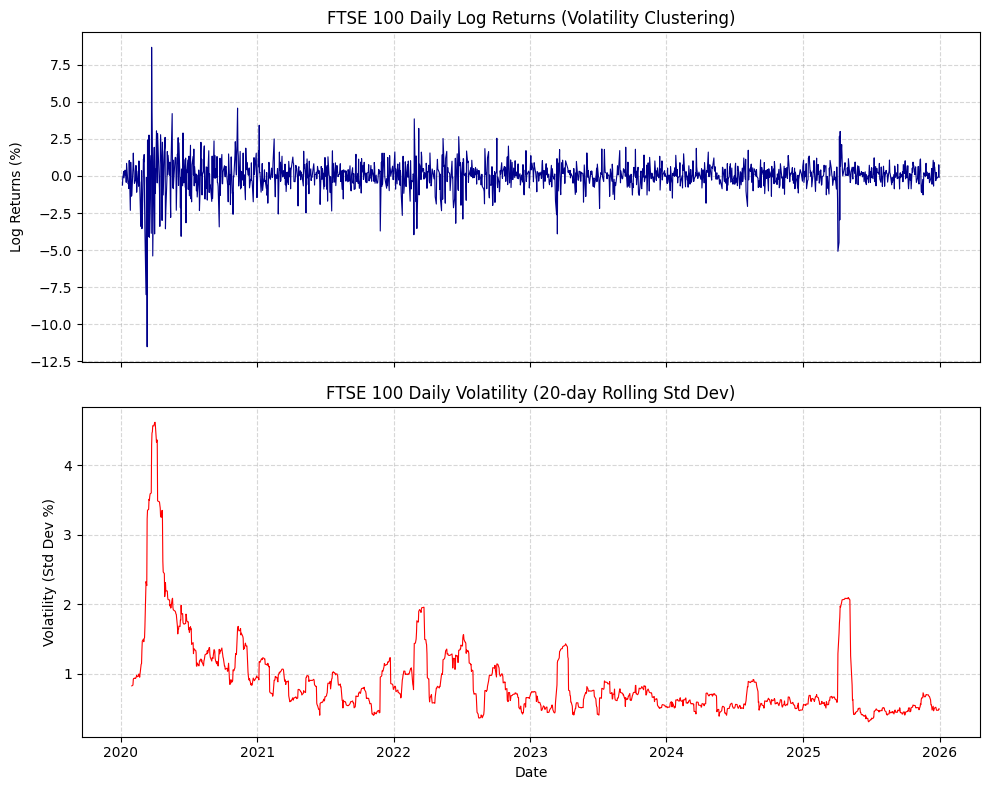

In [ ]:
import matplotlib.pyplot as plt

# Calculate rolling standard deviation for volatility
data['Volatility'] = data['Log_Returns'].rolling(window=20).std()

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Log Returns
axes[0].plot(data['Log_Returns'], color='darkblue', lw=0.8)
axes[0].set_title('FTSE 100 Daily Log Returns (Volatility Clustering)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_ylabel('Log Returns (%)')

# Plot Volatility (Rolling Standard Deviation)
axes[1].plot(data['Volatility'], color='red', lw=0.8)
axes[1].set_title('FTSE 100 Daily Volatility (20-day Rolling Std Dev)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_ylabel('Volatility (Std Dev %)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

# 2. Testing for ARCH Effects
Before applying a GARCH model, we must prove that the data exhibits conditional heteroskedasticity (volatility clustering). We run a Ljung-Box test on the squared returns to check for autocorrelation in variance.

In [ ]:
lb_test = acorr_ljungbox(data['Log_Returns']**2, lags=[5, 10], return_df=True)
print("\n--- Ljung-Box Test on Squared Returns ---")
print(lb_test)


--- Ljung-Box Test on Squared Returns ---
       lb_stat      lb_pvalue
5   376.330410   3.736973e-79
10  682.225421  4.103175e-140


We see that for both lag 5 and lag 10, the p-values are extremely small $(3.73 \times 10^{-79}$) and ($4.10 \times 10^{-140}$), far below common significance levels like 0.05. So we **reject** the null hypothesis and conclude that there is a significance autocorrelation in the squared returns. Because the returns are correlated, the variance is not constant overtime. Therefore we should use ARCH/GARCH model(s) to predict our volatility

# 3. Fitting the GARCH(1,1) Model
The standard GARCH(1,1) model splits return variance into three components: a baseline variance ($\omega$), yesterday's news/shock ($\alpha$), and yesterday's predicted variance ($\beta$).

\begin{align}
\sigma_t^2 = \omega + \alpha\epsilon_{t-1}^2 + \beta \sigma_{t-1}^2
\end{align}

Given that financial returns have heavy tails (leptokurtic), we will fit the model using a Student’s t-distribution instead of a Normal distribution for the error terms.


In [ ]:
# Fit GARCH(1,1) with a Student's t-distribution
model = arch_model(data['Log_Returns'], vol='Garch', p=1, q=1, dist='t')
res = model.fit(disp='off')

print("\n--- GARCH(1,1) Model Estimation Summary ---")
print(res.summary())

# Extract conditional volatility
data['GARCH_Vol'] = res.conditional_volatility


--- GARCH(1,1) Model Estimation Summary ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                  Log_Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1812.81
Distribution:      Standardized Student's t   AIC:                           3635.62
Method:                  Maximum Likelihood   BIC:                           3662.22
                                              No. Observations:                 1512
Date:                      Mon, May 18 2026   Df Residuals:                     1511
Time:                              19:32:19   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
------------------------------------

This is a very good model. All core parameters $\omega$, $\alpha$, $\beta$, and $\nu$ are highly statistically significant. Their $P>|t|$ values are extremely close to zero, sitting well below the standard 0.05 threshold.

The sum of your ARCH and GARCH parameters $(\alpha + \beta)$ is:
\begin{align}
0.1910+0.7564=0.9474
\end{align}

Because $\alpha + \beta = 0.9474 < 1$, the conditional variance is stationary and exhibits mean reversion to its long-run average.

# 4. Quantifying Market Risk (Value at Risk)

Value at Risk (VaR) measures the maximum potential loss over a given time horizon at a specific confidence level ($1 - \alpha$). Using our GARCH conditional volatility ($\sigma_t$), the parametric GARCH-VaR is calculated as:$$\text{VaR}_{t} = -\left( \mu_t + t_{\nu, \alpha} \times \sigma_t \right)$$Where $t_{\nu, \alpha}$ is the $\alpha$-quantile of the Student's t-distribution with $\nu$ degrees of freedom estimated by the model.

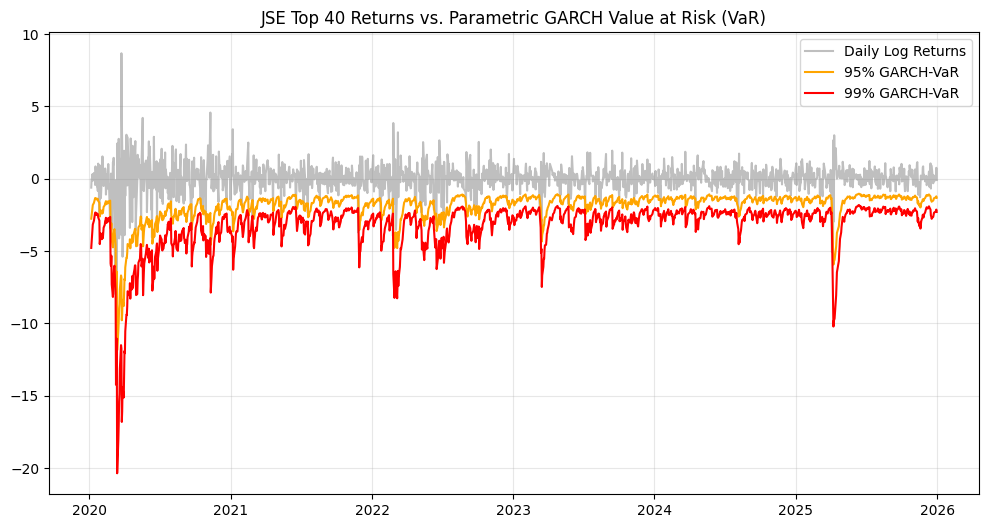

In [ ]:
# Compute 1-day ahead 95% and 99% Parametric GARCH-VaR
# Retrieve estimated degrees of freedom (nu) and mean (mu)
nu = res.params['nu']
mu = res.params['mu']

# Calculate distribution quantiles
q_95 = stats.t.ppf(0.05, df=nu)
q_99 = stats.t.ppf(0.01, df=nu)

# Calculate time-varying VaR (Note: scaling back by 100 if returns were scaled)
data['VaR_95'] = -(mu + q_95 * data['GARCH_Vol'])
data['VaR_99'] = -(mu + q_99 * data['GARCH_Vol'])

# Plot returns vs VaR thresholds
plt.figure(figsize=(12, 6))
plt.plot(data['Log_Returns'], color='gray', alpha=0.5, label='Daily Log Returns')
plt.plot(-data['VaR_95'], color='orange', label='95% GARCH-VaR', lw=1.5)
plt.plot(-data['VaR_99'], color='red', label='99% GARCH-VaR', lw=1.5)
plt.title('JSE Top 40 Returns vs. Parametric GARCH Value at Risk (VaR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#5. Model Backtesting (Kupiec's POF Test)
Now let's evaluate this model. A VaR breach (or exception) occurs when the actual loss exceeds the predicted VaR. Kupiec's Proportion of Failure (POF) test evaluates whether the observed number of breaches ($x$) matches the expected number of breaches ($N \times \alpha$) using a Likelihood Ratio ($LR$) test:$$LR_{POF} = -2 \ln \left[ \frac{(1-\alpha)^{N-x} \alpha^x}{(1-\hat{p})^{N-x} \hat{p}^x} \right] \sim \chi^2(1)$$

In [ ]:
def kupiec_pof_test(returns, var_threshold, alpha):
    N = len(returns)
    # A breach occurs when the actual negative return is worse than the VaR threshold
    breaches = np.sum(returns < -var_threshold)
    p_hat = breaches / N

    # Avoid division by zero/log errors
    if breaches == 0:
        return breaches, 1.0, "Pass"

    # Likelihood Ratio formula
    part_null = ((1 - alpha) ** (N - breaches)) * (alpha ** breaches)
    part_alt = ((1 - p_hat) ** (N - breaches)) * (p_hat ** breaches)

    lr = -2 * np.log(part_null / part_alt)
    p_value = 1 - stats.chi2.cdf(lr, df=1)

    status = "Reject Model (Fail)" if p_value < 0.05 else "Accept Model (Pass)"
    return breaches, p_value, status

# Backtest both models
b_95, p_95, status_95 = kupiec_pof_test(data['Log_Returns'], data['VaR_95'], 0.05)
b_99, p_99, status_99 = kupiec_pof_test(data['Log_Returns'], data['VaR_99'], 0.01)

print("\n--- VaR Backtesting Results (Kupiec POF Test) ---")
print(f"95% Confidence Level: Breaches = {b_95}/{len(data)} | P-value = {p_95:.4f} | Result: {status_95}")
print(f"99% Confidence Level: Breaches = {b_99}/{len(data)} | P-value = {p_99:.4f} | Result: {status_99}")


--- VaR Backtesting Results (Kupiec POF Test) ---
95% Confidence Level: Breaches = 50/1512 | P-value = 0.0013 | Result: Reject Model (Fail)
99% Confidence Level: Breaches = 7/1512 | P-value = 0.0190 | Result: Reject Model (Fail)


# Conclusion
Despite the statistically significant parameters in the GARCH(1,1) model, the Kupiec's POF backtest indicates that our model is currently inadequate for accurately predicting VaR at both the 95% and 99% confidence levels. The model was rejected, meaning it systematically underestimates the risk by producing a higher number of breaches than expected. This suggests that while the model captures some aspects of volatility, it doesn't fully account for the extreme movements or tail risks in the FTSE 100.